In [2]:
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import cartopy.crs as ccrs
import matplotlib.ticker as mticker
import iris
import esmpy

In [6]:
# Load a test mask 
TEST_DIR = Path('/home/548/pag548/code/UM_config_tools')

In [7]:
test_MOM = xr.load_dataarray(TEST_DIR / 'test_upscale.nc')

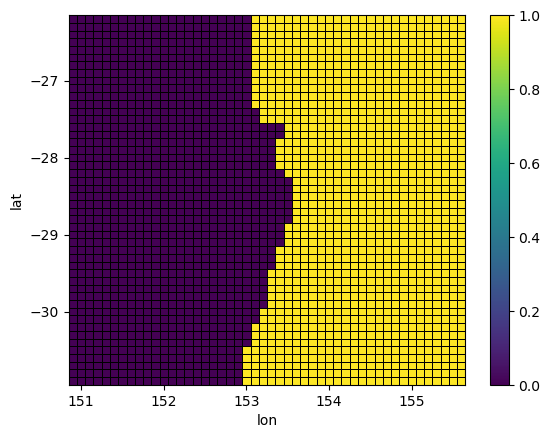

In [9]:
test_MOM.plot(edgecolors='black',linewidth=0.5)

In [25]:
print (f"""
Bounds of Domain are {test_MOM.lat.data.min()},{test_MOM.lat.data.max():.1f} latitude
                     {test_MOM.lon.data.min()}, {test_MOM.lon.data.max():.1f} longitude""")


Bounds of Domain are -30.9,-26.2 latitude
                     150.9, 155.6 longitude


In [28]:
# What if we naively try upscaling by by factor of 2?
test_MOM.lat.data

array([-30.9, -30.8, -30.7, -30.6, -30.5, -30.4, -30.3, -30.2, -30.1,
       -30. , -29.9, -29.8, -29.7, -29.6, -29.5, -29.4, -29.3, -29.2,
       -29.1, -29. , -28.9, -28.8, -28.7, -28.6, -28.5, -28.4, -28.3,
       -28.2, -28.1, -28. , -27.9, -27.8, -27.7, -27.6, -27.5, -27.4,
       -27.3, -27.2, -27.1, -27. , -26.9, -26.8, -26.7, -26.6, -26.5,
       -26.4, -26.3, -26.2])

In [30]:
test_MOM.lat.isel(lat=slice(0, None, 2)).data

array([-30.9, -30.7, -30.5, -30.3, -30.1, -29.9, -29.7, -29.5, -29.3,
       -29.1, -28.9, -28.7, -28.5, -28.3, -28.1, -27.9, -27.7, -27.5,
       -27.3, -27.1, -26.9, -26.7, -26.5, -26.3])

In [86]:
# It won't respect the corners for fields defined on vertices. So we'll have to do it another way

In [39]:
# Load the frankenmodel grids
FR_DIR = Path('/g/data/gb02/ab8992/frankenmodel-rundir')
fr_mask, = iris.load( FR_DIR / 'um_inputfiles/ancils/qrparm.mask')

In [40]:
fr_mask_da = xr.DataArray.from_iris(fr_mask)

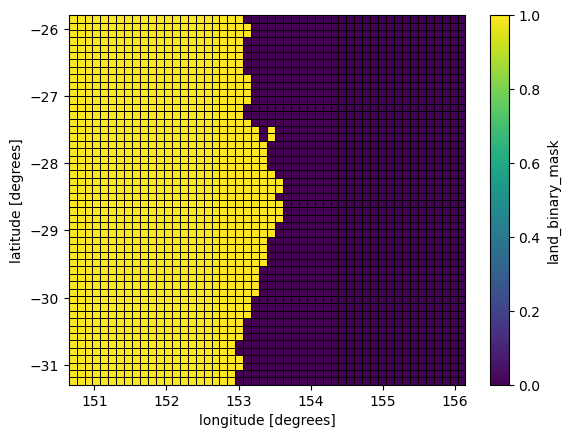

In [43]:
fr_mask_da.plot(edgecolors='black',linewidth=0.5)

In [45]:
fr_mesh = xr.load_dataset( FR_DIR / 'mom_inputfiles/access-rom3-ESMFmesh.nc')
fr_hgrid = xr.load_dataset( FR_DIR / 'mom_inputfiles/hgrid.nc')

In [132]:
geo_lon_t = fr_hgrid.x[1::2,1::2]
geo_lat_t = fr_hgrid.y[1::2,1::2]

lons = geo_lon_t.values[0,:]
lats = geo_lat_t.values[:,0]

nx = len(lons)
ny = len(lats)

fr_da = xr.DataArray(fr_mesh.elementMask.values.reshape(ny,nx),
                        dims=['lat','lon'],
                        coords={'lat':lats, 
                                'lon':lons})

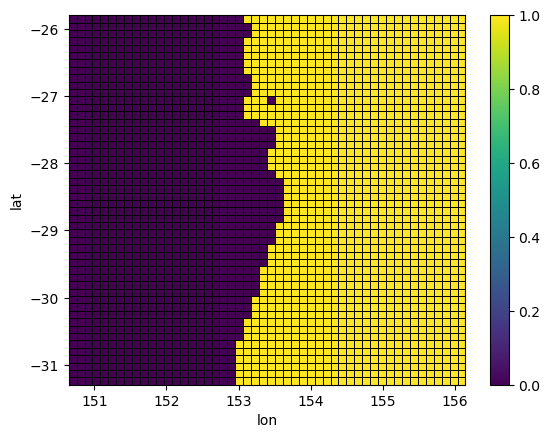

In [133]:
fr_da.plot(edgecolors='black',linewidth=0.5)

In [134]:
# These are the same latitude values
(lats-fr_mask_da.latitude.data).sum()

-9.536743075244658e-06

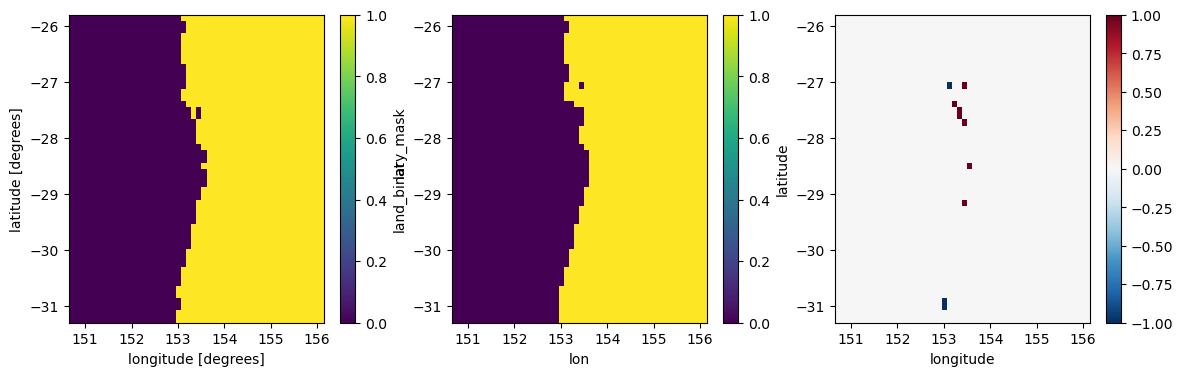

In [136]:
# But these masks aren't the same! 
fig,ax=plt.subplots(1,3,figsize=(14,4))
fr_invert = (1-fr_mask_da)
fr_invert.plot(ax=ax[0])
fr_da.plot(ax=ax[1])
delta = fr_invert.data.compute() - fr_da.data
delta_da = xr.DataArray(delta,
                        dims=['latitude','longitude'],
                        coords={'latitude':lats, 
                                'longitude':lons})
delta_da.plot(ax=ax[2])

In [129]:
fr_invert.data.compute() -fr_ds.data


array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [124]:
fr_invert.drop_attrs().compute()

<xarray.DataArray 'land_binary_mask' (latitude: 50, longitude: 50)> Size: 20kB
array([[0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       ...,
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1]])
Coordinates:
  * latitude   (latitude) float32 200B -31.24 -31.13 -31.02 ... -25.96 -25.85
  * longitude  (longitude) float32 200B 150.7 150.8 150.9 ... 155.9 156.0 156.1

In [64]:
# Now, based on this issue over velocity at the Eastern Edge, https://github.com/21centuryweather/rCM3-ancil-suite/issues/1#issuecomment-4265929769,
# let's add an extra value of longitude along the eastern edge
shape = list(fr_mask.data.shape)
new_shape = [shape[0]+1,shape[1]]
new_data = np.array([new_shape])

In [72]:
dx = np.round(lons[1]-lons[0],2)
new_lons = np.append(lons,lons[-1]+dx)

In [73]:
new_lons

array([150.7 , 150.81, 150.92, 151.03, 151.14, 151.25, 151.36, 151.47,
       151.58, 151.69, 151.8 , 151.91, 152.02, 152.13, 152.24, 152.35,
       152.46, 152.57, 152.68, 152.79, 152.9 , 153.01, 153.12, 153.23,
       153.34, 153.45, 153.56, 153.67, 153.78, 153.89, 154.  , 154.11,
       154.22, 154.33, 154.44, 154.55, 154.66, 154.77, 154.88, 154.99,
       155.1 , 155.21, 155.32, 155.43, 155.54, 155.65, 155.76, 155.87,
       155.98, 156.09, 156.2 ])

0.11

In [71]:
np.round(dx,2)

0.11